## TimesFM


### Model Overview: TimesFM

[Google Research's TimesFM](https://arxiv.org/abs/2310.10688) ("A decoder-only foundation model for time-series forecasting", Das et al., ICML 2024) is a patched-decoder attention model pretrained on roughly 100 billion real-world time points drawn from Google Trends, Wikipedia page views, and other public time-series corpora. Unlike DLinear and TFT in the other notebooks here, TimesFM is **not trained from scratch on the Walmart data** - it is used zero-shot: the pretrained weights stay frozen, and the model forecasts directly from a raw history window ("context") handed to it at inference time.

This notebook uses **TimesFM 2.5** (`google/timesfm-2.5-200m-pytorch`):
- 200M parameters (down from 500M in TimesFM 2.0), supporting up to 16K context tokens (up from 2048 in 2.0)
- an optional ~30M-parameter continuous quantile head for probabilistic forecasts (kept off here - WMAE only needs point forecasts)
- currently tops the [GIFT-Eval](https://arxiv.org/pdf/2410.10393) leaderboard among zero-shot foundation models

**Why the sweep looks different from DLinear/TFT:** there is no gradient training here, so "hyperparameters" become inference-time configuration instead - how much history to hand the model (`context_length`), and whether/how to fold in known future covariates. `forecast_with_covariates` fits a small per-series ridge/linear regression on the covariates and combines it with TimesFM's own zero-shot forecast (`xreg_mode`: `"xreg + timesfm"` fits the linear model first and lets TimesFM forecast the residual, `"timesfm + xreg"` does the reverse). The `underfit / balanced / overfit`-style regime labels from the other notebooks are relabeled `zero_shot / covariates / unregularized_xreg` to reflect what's actually varying: there's no training loss to overfit, but the per-series linear covariate model *can* genuinely overfit short, noisy histories when its ridge penalty is 0.

Sources:
- [A decoder-only foundation model for time-series forecasting (arXiv:2310.10688)](https://arxiv.org/abs/2310.10688)
- [google/timesfm-2.5-200m-pytorch model card (Hugging Face)](https://huggingface.co/google/timesfm-2.5-200m-pytorch)
- [Google AI Ships TimesFM-2.5 (MarkTechPost)](https://www.marktechpost.com/2025/09/16/google-ai-ships-timesfm-2-5-smaller-longer-context-foundation-model-that-now-leads-gift-eval-zero-shot-forecasting/)


### 1. Setup and Imports


In [1]:
import os
import sys
import importlib
from pathlib import Path

os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib"))
os.environ.setdefault("NIXTLA_ID_AS_COL", "1")

repo_root = Path.cwd()
while repo_root != repo_root.parent:
    if (repo_root / "src").exists():
        sys.path.insert(0, str(repo_root))
        break
    repo_root = repo_root.parent
else:
    raise FileNotFoundError("Could not locate the repository root containing 'src'.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
import mlflow.pyfunc
from mlflow.models import infer_signature

import wandb

import timesfm

import src.mlflow_setup as mlflow_setup
importlib.reload(mlflow_setup)
init_tracking = mlflow_setup.init_tracking
from src.data_loading import load_merged, load_features
from src.transforms import apply_shared_features, build_store_date_features
from src.validation import time_based_split
from src.metrics import wmae_from_df
from src.pipeline.timesfm_pipeline import (
    to_long_format,
    to_static_format,
    TimesFMForecastPipeline,
)

# TimesFM is a frozen pretrained model at inference time - there is no backward
# pass, so unlike the DLinear/TFT notebooks there is no GradientNormLogger here.

init_tracking()
assert "dagshub.com" in mlflow.get_tracking_uri(), mlflow.get_tracking_uri()

if mlflow.active_run() is not None:
    mlflow.end_run()

BLUE   = "#7196C7"
PURPLE = "#705588"
RED    = "#7E3838"

REGIME_COLORS = {
    "zero_shot": PURPLE,
    "covariates": BLUE,
    "unregularized_xreg": RED,
}

print("Current MLflow URI:", mlflow.get_tracking_uri())
print("Setup complete.")

c:\Users\l.chitishvili\Desktop\ml\ml-final-project-store-sales-forecasting\.venv\Lib\site-packages\mlflow\pyfunc\utils\data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


Accessing as lchit22

Initialized MLflow to track repo "dkhak22/ml-final-project-store-sales-forecasting"

Repository dkhak22/ml-final-project-store-sales-forecasting initialized!

MLflow tracking URI: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow
Current MLflow URI: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow
Setup complete.


### 2. Configuration


In [2]:
EXPERIMENT_NAME = "TimesFM_Training"
mlflow.set_experiment(EXPERIMENT_NAME)

WANDB_ENTITY = "dkhak22-free-university-of-tbilisi-"
WANDB_PROJECT = "walmart-sales-forecasting"

REPO_ID = "google/timesfm-2.5-200m-pytorch"
MODEL_COL = "TimesFM"

CONFIG = {
    "context_length": 104,
    "horizon": 26,
    "use_covariates": True,
    "xreg_mode": "xreg + timesfm",
    "ridge": 1.0,
    "use_quantile_head": False,
    "random_seed": 42,
}

FREQ = "W-FRI"

CONFIG

2026/07/12 21:11:14 INFO mlflow.tracking.fluent: Experiment with name 'TimesFM_Training' does not exist. Creating a new experiment.


{'context_length': 104,
 'horizon': 26,
 'use_covariates': True,
 'xreg_mode': 'xreg + timesfm',
 'ridge': 1.0,
 'use_quantile_head': False,
 'random_seed': 42}

### 3. Load Data


In [3]:
train_df, test_df = load_merged()

print(f"train_df: {train_df.shape}")
print(f"test_df:  {test_df.shape}")

CONFIG["horizon"] = test_df["Date"].nunique()
train_df.head()

train_df: (421570, 16)
test_df:  (115064, 15)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


### 4. Shared Preprocessing and Feature Engineering


In [4]:
train_prepared = apply_shared_features(train_df)

print(f"train_prepared: {train_prepared.shape}")
train_prepared.head()

train_prepared: (421570, 23)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Unemployment,Size,Type_A,Type_B,Type_C,Year,Month,WeekOfYear,DaysSinceLastHoliday,DaysToNextHoliday
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,5,inf,7.0
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,6,0.0,0.0
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,7,7.0,203.0
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,8,14.0,196.0
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,3,9,21.0,189.0


In [5]:
inf_check = np.isinf(train_prepared.select_dtypes(include=[np.number])).sum()
print(inf_check[inf_check > 0])

for col in ["DaysSinceLastHoliday", "DaysToNextHoliday"]:
    if col in train_prepared.columns:
        finite_vals = train_prepared.loc[np.isfinite(train_prepared[col]), col]
        cap = finite_vals.max() if len(finite_vals) else 0
        train_prepared[col] = train_prepared[col].replace([np.inf, -np.inf], cap)

DaysSinceLastHoliday    2955
dtype: int64


### 5. Model-Specific Feature Selection


In [6]:
FUTR_COLS = [
    "IsHoliday",
    "Temperature",
    "Fuel_Price",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",
    "CPI",
    "Unemployment",
    "Year",
    "Month",
    "WeekOfYear",
    "DaysSinceLastHoliday",
    "DaysToNextHoliday",
]
FUTR_COLS = [col for col in FUTR_COLS if col in train_prepared.columns]

STATIC_NUM_COLS = [col for col in ["Size", "Type_A", "Type_B", "Type_C"] if col in train_prepared.columns]
STATIC_CAT_COLS = ["Store", "Dept"]

TIMESFM_FEATURE_DECISION = {
    "feature_set": "future_and_static_exogenous_via_xreg",
    "uses_exogenous_features": True,
    "future_exogenous_columns": FUTR_COLS,
    "static_numerical_columns": STATIC_NUM_COLS,
    "static_categorical_columns": STATIC_CAT_COLS,
    "reason": (
        "TimesFM is a frozen, zero-shot decoder-only foundation model - it is not "
        "a neuralforecast model, so it has no EXOGENOUS_FUTR/HIST/STAT class flags "
        "to introspect the way TFT/DLinear do. Covariate support instead comes "
        "from `forecast_with_covariates`, which fits a per-series ridge/linear "
        "model on the given dynamic and static covariates and combines it with "
        "TimesFM's zero-shot forecast. This experiment reuses the same "
        "calendar/holiday/markdown/economic/weather/store/department features as "
        "the TFT experiment so the two notebooks are directly comparable."
    ),
}

print("Future exogenous columns:", FUTR_COLS)
print("Static numerical columns:", STATIC_NUM_COLS)
print("Static categorical columns:", STATIC_CAT_COLS)
TIMESFM_FEATURE_DECISION

Future exogenous columns: ['IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Year', 'Month', 'WeekOfYear', 'DaysSinceLastHoliday', 'DaysToNextHoliday']
Static numerical columns: ['Size', 'Type_A', 'Type_B', 'Type_C']
Static categorical columns: ['Store', 'Dept']


{'feature_set': 'future_and_static_exogenous_via_xreg',
 'uses_exogenous_features': True,
 'future_exogenous_columns': ['IsHoliday',
  'Temperature',
  'Fuel_Price',
  'MarkDown1',
  'MarkDown2',
  'MarkDown3',
  'MarkDown4',
  'MarkDown5',
  'CPI',
  'Unemployment',
  'Year',
  'Month',
  'WeekOfYear',
  'DaysSinceLastHoliday',
  'DaysToNextHoliday'],
 'static_numerical_columns': ['Size', 'Type_A', 'Type_B', 'Type_C'],
 'static_categorical_columns': ['Store', 'Dept'],
 'reason': "TimesFM is a frozen, zero-shot decoder-only foundation model - it is not a neuralforecast model, so it has no EXOGENOUS_FUTR/HIST/STAT class flags to introspect the way TFT/DLinear do. Covariate support instead comes from `forecast_with_covariates`, which fits a per-series ridge/linear model on the given dynamic and static covariates and combines it with TimesFM's zero-shot forecast. This experiment reuses the same calendar/holiday/markdown/economic/weather/store/department features as the TFT experiment so t

### 6. Time-Series and Window Setup


In [7]:
train_part, valid_part = time_based_split(train_prepared, valid_weeks=CONFIG["horizon"])

print(f"Train part: {train_part['Date'].min().date()} -> {train_part['Date'].max().date()}")
print(f"Valid part: {valid_part['Date'].min().date()} -> {valid_part['Date'].max().date()}")
print(f"\nContext length: {CONFIG['context_length']} weeks")
print(f"Forecast horizon: {CONFIG['horizon']} weeks")

long_df = to_long_format(train_prepared, include_target=True, futr_cols=FUTR_COLS)
series_lengths = long_df.groupby("unique_id").size()
TIMESFM_SERIES_LENGTH = int(series_lengths.max())
timesfm_ids = series_lengths[series_lengths == TIMESFM_SERIES_LENGTH].index
timesfm_df = long_df[long_df["unique_id"].isin(timesfm_ids)].copy()
static_df = to_static_format(train_prepared, static_cols=STATIC_NUM_COLS + STATIC_CAT_COLS)
static_df = static_df[static_df["unique_id"].isin(timesfm_ids)].reset_index(drop=True)

print("\nSeries length summary:")
display(series_lengths.describe())
print("\nTimesFM evaluation frame:")
print(f"Using {timesfm_df['unique_id'].nunique()} complete-history Store-Dept series")
print(f"Dropping {long_df['unique_id'].nunique() - timesfm_df['unique_id'].nunique()} short/ragged series")
print(f"Rows used by TimesFM: {timesfm_df.shape[0]:,}")
print(f"Static rows used by TimesFM: {static_df.shape[0]:,}")

holiday_lookup = train_prepared.assign(
    unique_id=train_prepared["Store"].astype(str) + "_" + train_prepared["Dept"].astype(str),
    ds=train_prepared["Date"],
)[["unique_id", "ds", "IsHoliday"]].drop_duplicates()
holiday_lookup["IsHoliday"] = holiday_lookup["IsHoliday"].fillna(False).astype(bool)


def run_timesfm_cv(
    model,
    long_df,
    unique_ids,
    valid_start_ds,
    horizon,
    context_length,
    futr_cols,
    static_df=None,
    static_num_cols=None,
    static_cat_cols=None,
    use_covariates=False,
    xreg_mode="xreg + timesfm",
    ridge=1.0,
):
    """Backtests TimesFM on a single held-out validation window.

    NeuralForecast models expose `.cross_validation(...)`; TimesFM has no such
    helper since it is never fitted to a dataset, so this rebuilds the
    equivalent by hand: feed each series' pre-cutoff history as context and
    check the forecast against the actual held-out values.
    """
    history_df = long_df[long_df["ds"] < valid_start_ds]
    valid_df = long_df[long_df["ds"] >= valid_start_ds]

    inputs = []
    dyn_num = {c: [] for c in futr_cols} if use_covariates else None
    static_num = {c: [] for c in (static_num_cols or [])} if use_covariates else None
    static_cat = {c: [] for c in (static_cat_cols or [])} if use_covariates else None

    static_by_id = static_df.set_index("unique_id") if static_df is not None else None
    valid_rows_by_id = {}
    kept_ids = []

    for uid in unique_ids:
        hist = history_df[history_df["unique_id"] == uid].sort_values("ds")
        val = valid_df[valid_df["unique_id"] == uid].sort_values("ds")
        if len(val) != horizon or hist.empty:
            continue

        if len(hist) > context_length:
            hist = hist.iloc[-context_length:]

        kept_ids.append(uid)
        inputs.append(hist["y"].to_numpy(dtype=np.float32))
        valid_rows_by_id[uid] = val

        if use_covariates:
            for c in futr_cols:
                dyn_num[c].append(
                    np.concatenate([
                        hist[c].to_numpy(dtype=np.float32),
                        val[c].to_numpy(dtype=np.float32),
                    ])
                )
            static_row = (
                static_by_id.loc[uid]
                if (static_by_id is not None and uid in static_by_id.index)
                else None
            )
            for c in (static_num_cols or []):
                static_num[c].append(float(static_row[c]) if static_row is not None else 0.0)
            for c in (static_cat_cols or []):
                static_cat[c].append(int(static_row[c]) if static_row is not None else 0)

    if use_covariates:
        outputs, _xreg_outputs = model.forecast_with_covariates(
            inputs=inputs,
            dynamic_numerical_covariates=dyn_num,
            static_numerical_covariates=static_num or None,
            static_categorical_covariates=static_cat or None,
            xreg_mode=xreg_mode,
            ridge=ridge,
        )
    else:
        point, _quantiles = model.forecast(horizon=horizon, inputs=inputs)
        outputs = list(point)

    rows = []
    for uid, series_out in zip(kept_ids, outputs):
        series_out = np.asarray(series_out).reshape(-1)[:horizon]
        val = valid_rows_by_id[uid]
        for ds, y_true, pred in zip(val["ds"], val["y"], series_out):
            rows.append((uid, ds, y_true, float(pred)))

    return pd.DataFrame(rows, columns=["unique_id", "ds", "y", MODEL_COL])

Train part: 2010-02-05 -> 2012-01-27
Valid part: 2012-02-03 -> 2012-10-26

Context length: 104 weeks
Forecast horizon: 39 weeks

Series length summary:


count    3331.000000
mean      126.559592
std        40.212763
min         1.000000
25%       143.000000
50%       143.000000
75%       143.000000
max       143.000000
dtype: float64


TimesFM evaluation frame:
Using 2660 complete-history Store-Dept series
Dropping 671 short/ragged series
Rows used by TimesFM: 380,380
Static rows used by TimesFM: 2,660


### 7. Forward and Backward Check


In [8]:
tiny_ids = timesfm_df["unique_id"].unique()[:5]

model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(REPO_ID)
model.compile(
    timesfm.ForecastConfig(
        max_context=CONFIG["context_length"],
        max_horizon=CONFIG["horizon"],
        normalize_inputs=True,
        use_continuous_quantile_head=CONFIG["use_quantile_head"],
        return_backcast=True,
    )
)

sanity_cv = run_timesfm_cv(
    model,
    timesfm_df,
    tiny_ids,
    valid_start_ds=valid_part["Date"].min(),
    horizon=CONFIG["horizon"],
    context_length=CONFIG["context_length"],
    futr_cols=FUTR_COLS,
    static_df=static_df,
    static_num_cols=STATIC_NUM_COLS,
    static_cat_cols=STATIC_CAT_COLS,
    use_covariates=True,
    xreg_mode=CONFIG["xreg_mode"],
    ridge=CONFIG["ridge"],
)

expected_rows = len(tiny_ids) * CONFIG["horizon"]
assert len(sanity_cv) == expected_rows
assert sanity_cv[MODEL_COL].notna().all()

print("TimesFM sanity check passed:", sanity_cv.shape)
display(sanity_cv.head())

TimesFM sanity check passed: (195, 4)


,unique_id,ds,y,TimesFM
0,10_1,2012-02-03,36444.00,201640.140625
1,10_1,2012-02-10,50434.11,67798.164062
2,10_1,2012-02-17,74930.33,46098.195312
3,10_1,2012-02-24,28751.57,13832.457031
4,10_1,2012-03-02,30525.88,48096.339844


### 8. Baseline Run


In [9]:
baseline_config = CONFIG.copy()
baseline_config["label"] = "baseline_zero_shot"

with mlflow.start_run(run_name="TimesFM_Baseline") as run:
    wandb.init(
        entity=WANDB_ENTITY,
        project=WANDB_PROJECT,
        name="TimesFM_Baseline",
        group="TimesFM",
        job_type="baseline",
        tags=["TimesFM", "baseline", "zero_shot"],
        config={**baseline_config, **TIMESFM_FEATURE_DECISION},
        reinit=True,
    )

    try:
        model.compile(
            timesfm.ForecastConfig(
                max_context=CONFIG["context_length"],
                max_horizon=CONFIG["horizon"],
                normalize_inputs=True,
                use_continuous_quantile_head=CONFIG["use_quantile_head"],
                return_backcast=False,
            )
        )

        cv_df = run_timesfm_cv(
            model,
            timesfm_df,
            timesfm_df["unique_id"].unique(),
            valid_start_ds=valid_part["Date"].min(),
            horizon=CONFIG["horizon"],
            context_length=CONFIG["context_length"],
            futr_cols=FUTR_COLS,
            use_covariates=False,
        )
        cv_df = cv_df.merge(holiday_lookup, on=["unique_id", "ds"], how="left")
        cv_df["IsHoliday"] = cv_df["IsHoliday"].fillna(False).astype(bool)

        val_wmae = wmae_from_df(cv_df, y_true_col="y", y_pred_col=MODEL_COL, holiday_col="IsHoliday")
        print(f"Baseline (zero-shot) validation WMAE: {val_wmae:,.2f}")

        mlflow.log_params({**baseline_config, "future_exogenous_columns": ",".join(FUTR_COLS)})
        mlflow.log_param("timesfm_n_series", timesfm_df["unique_id"].nunique())
        mlflow.log_metric("val_wmae", val_wmae)
        mlflow.log_param("gradient_logging", False)
        mlflow.log_param(
            "gradient_logging_reason",
            "TimesFM is a frozen pretrained model at inference time - there is no backward pass to log.",
        )

        wandb.log({"val_wmae": val_wmae})

        baseline_run_id = run.info.run_id
    finally:
        wandb.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\l.chitishvili\_netrc.
wandb: Currently logged in as: lchit22 (lchit22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Baseline (zero-shot) validation WMAE: 1,815.32


val_wmae,▁
val_wmae,1815.32466


🏃 View run TimesFM_Baseline at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/6/runs/986a29db0e6d4e40b12f6c353099dd69
🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/6


### 9. Configurations


In [10]:
param_grid = [
    # --- zero_shot: no covariates at all, only context length varies ---
    {"label": "zero_shot_1", "regime": "zero_shot", "context_length": 13,  "use_covariates": False, "xreg_mode": None, "ridge": None},
    {"label": "zero_shot_2", "regime": "zero_shot", "context_length": 26,  "use_covariates": False, "xreg_mode": None, "ridge": None},
    {"label": "zero_shot_3", "regime": "zero_shot", "context_length": 52,  "use_covariates": False, "xreg_mode": None, "ridge": None},
    {"label": "zero_shot_4", "regime": "zero_shot", "context_length": 78,  "use_covariates": False, "xreg_mode": None, "ridge": None},
    {"label": "zero_shot_5", "regime": "zero_shot", "context_length": 104, "use_covariates": False, "xreg_mode": None, "ridge": None},
    {"label": "zero_shot_6", "regime": "zero_shot", "context_length": 130, "use_covariates": False, "xreg_mode": None, "ridge": None},

    # --- covariates: regularized xreg + timesfm, the main sweep ---
    {"label": "covariates_1", "regime": "covariates", "context_length": 52,  "use_covariates": True, "xreg_mode": "xreg + timesfm", "ridge": 5.0},
    {"label": "covariates_2", "regime": "covariates", "context_length": 52,  "use_covariates": True, "xreg_mode": "xreg + timesfm", "ridge": 1.0},
    {"label": "covariates_3", "regime": "covariates", "context_length": 78,  "use_covariates": True, "xreg_mode": "xreg + timesfm", "ridge": 1.0},
    {"label": "covariates_4", "regime": "covariates", "context_length": 78,  "use_covariates": True, "xreg_mode": "timesfm + xreg", "ridge": 1.0},
    {"label": "covariates_5", "regime": "covariates", "context_length": 104, "use_covariates": True, "xreg_mode": "xreg + timesfm", "ridge": 1.0},
    {"label": "covariates_6", "regime": "covariates", "context_length": 104, "use_covariates": True, "xreg_mode": "timesfm + xreg", "ridge": 5.0},
    {"label": "covariates_7", "regime": "covariates", "context_length": 130, "use_covariates": True, "xreg_mode": "xreg + timesfm", "ridge": 5.0},
    {"label": "covariates_8", "regime": "covariates", "context_length": 130, "use_covariates": True, "xreg_mode": "timesfm + xreg", "ridge": 1.0},

    # --- unregularized_xreg: ridge=0 lets the per-series linear covariate model
    # fit noise in short/volatile histories instead of a stable trend ---
    {"label": "unregularized_1", "regime": "unregularized_xreg", "context_length": 130, "use_covariates": True, "xreg_mode": "xreg + timesfm", "ridge": 0.0},
    {"label": "unregularized_2", "regime": "unregularized_xreg", "context_length": 156, "use_covariates": True, "xreg_mode": "xreg + timesfm", "ridge": 0.0},
    {"label": "unregularized_3", "regime": "unregularized_xreg", "context_length": 182, "use_covariates": True, "xreg_mode": "xreg + timesfm", "ridge": 0.0},
    {"label": "unregularized_4", "regime": "unregularized_xreg", "context_length": 130, "use_covariates": True, "xreg_mode": "timesfm + xreg", "ridge": 0.0},
    {"label": "unregularized_5", "regime": "unregularized_xreg", "context_length": 156, "use_covariates": True, "xreg_mode": "timesfm + xreg", "ridge": 0.0},
    {"label": "unregularized_6", "regime": "unregularized_xreg", "context_length": 182, "use_covariates": True, "xreg_mode": "timesfm + xreg", "ridge": 0.0},
]

print(f"Total TimesFM configs: {len(param_grid)}")

Total TimesFM configs: 20


### 10. TimesFM Experiments


In [ ]:
results = []
cv_by_label = {}
best_val_wmae = float("inf")
best_run_id = None
best_label = None

with mlflow.start_run(run_name="TimesFM_ConfigSweep") as parent_run:
    mlflow.log_param("n_configs", len(param_grid))
    mlflow.log_param("model", "TimesFM")
    mlflow.log_param("repo_id", REPO_ID)
    mlflow.log_param("feature_set", TIMESFM_FEATURE_DECISION["feature_set"])
    mlflow.log_param("timesfm_n_series", timesfm_df["unique_id"].nunique())

    for params in param_grid:
        label = params["label"]
        with mlflow.start_run(run_name=f"TimesFM_{label}", nested=True) as nested_run:
            wandb.init(
                entity=WANDB_ENTITY,
                project=WANDB_PROJECT,
                name=f"TimesFM_{label}",
                group="TimesFM",
                job_type="config_sweep",
                tags=["TimesFM", params["regime"], "covariates" if params["use_covariates"] else "zero_shot"],
                config={**params, **TIMESFM_FEATURE_DECISION},
                reinit=True,
            )
            try:
                model.compile(
                    timesfm.ForecastConfig(
                        max_context=params["context_length"],
                        max_horizon=CONFIG["horizon"],
                        normalize_inputs=True,
                        use_continuous_quantile_head=CONFIG["use_quantile_head"],
                        return_backcast=params["use_covariates"],
                    )
                )

                cv_df = run_timesfm_cv(
                    model,
                    timesfm_df,
                    timesfm_df["unique_id"].unique(),
                    valid_start_ds=valid_part["Date"].min(),
                    horizon=CONFIG["horizon"],
                    context_length=params["context_length"],
                    futr_cols=FUTR_COLS,
                    static_df=static_df,
                    static_num_cols=STATIC_NUM_COLS,
                    static_cat_cols=STATIC_CAT_COLS,
                    use_covariates=params["use_covariates"],
                    xreg_mode=params["xreg_mode"],
                    ridge=params["ridge"],
                )
                cv_df = cv_df.merge(holiday_lookup, on=["unique_id", "ds"], how="left")
                cv_df["IsHoliday"] = cv_df["IsHoliday"].fillna(False).astype(bool)
                val_wmae = wmae_from_df(cv_df, y_true_col="y", y_pred_col=MODEL_COL, holiday_col="IsHoliday")
                cv_by_label[label] = cv_df.copy()

                mlflow.log_params({
                    **params,
                    "future_exogenous_columns": ",".join(FUTR_COLS) if params["use_covariates"] else "",
                })
                mlflow.log_metric("val_wmae", val_wmae)
                mlflow.log_param("gradient_logging", False)

                wandb.log({"val_wmae": val_wmae})

                results.append({
                    **params,
                    "feature_set": TIMESFM_FEATURE_DECISION["feature_set"],
                    "val_wmae": val_wmae,
                    "run_id": nested_run.info.run_id,
                })

                if val_wmae < best_val_wmae:
                    best_val_wmae = val_wmae
                    best_run_id = nested_run.info.run_id
                    best_label = label
                    print(f"New best by validation WMAE: {best_label} | val WMAE = {best_val_wmae:,.2f}")
            finally:
                wandb.finish()

### 11. Results


In [12]:
results_df = pd.DataFrame(results).sort_values("val_wmae").reset_index(drop=True)

display_cols = ["label", "regime", "context_length", "use_covariates", "xreg_mode", "ridge", "val_wmae"]
display(results_df[display_cols].head(15))

os.makedirs("reports", exist_ok=True)
results_path = "reports/timesfm_results.csv"
results_df.to_csv(results_path, index=False)

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(results_path)

,label,regime,context_length,use_covariates,xreg_mode,ridge,val_wmae
0,zero_shot_5,zero_shot,104,False,None,NaN,1815.324658
1,zero_shot_6,zero_shot,130,False,None,NaN,1815.324672
2,zero_shot_4,zero_shot,78,False,None,NaN,1897.532849
3,covariates_7,covariates,130,True,xreg + timesfm,5.0,2067.950059
4,covariates_5,covariates,104,True,xreg + timesfm,1.0,2068.151065
5,unregularized_3,unregularized_xreg,182,True,xreg + timesfm,0.0,2068.200710
6,unregularized_2,unregularized_xreg,156,True,xreg + timesfm,0.0,2068.200715
7,unregularized_1,unregularized_xreg,130,True,xreg + timesfm,0.0,2068.200715
8,covariates_3,covariates,78,True,xreg + timesfm,1.0,2173.483439
9,unregularized_4,unregularized_xreg,130,True,timesfm + xreg,0.0,2405.967392


🏃 View run TimesFM_zero_shot_5 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/6/runs/aa247403c670487ea7cc4b5945c039e1
🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/6


### 12. Plots


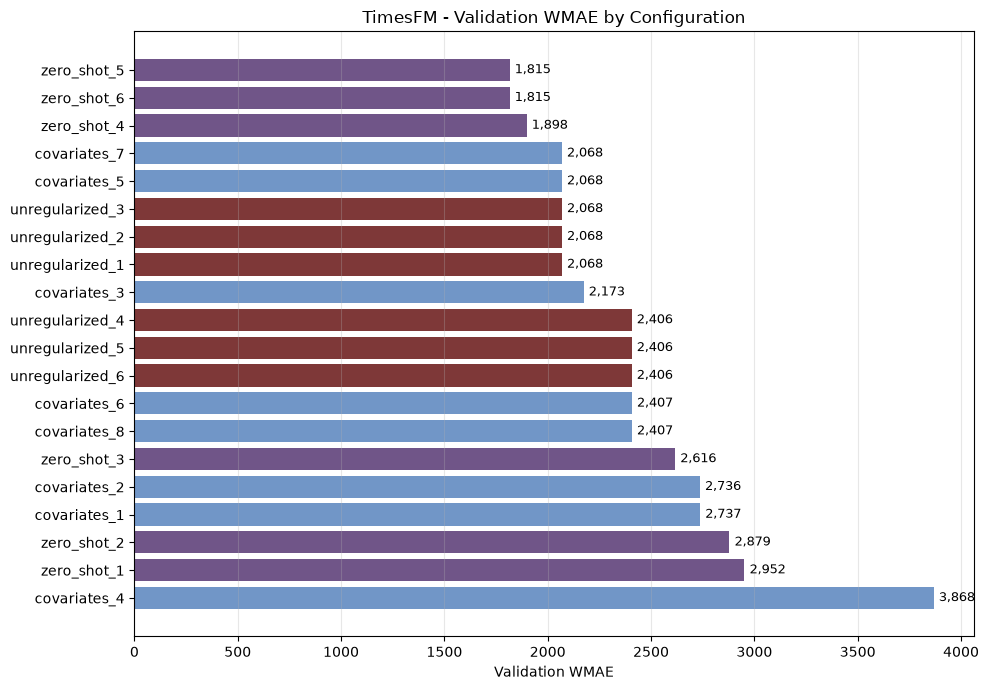

🏃 View run TimesFM_zero_shot_5 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/6/runs/aa247403c670487ea7cc4b5945c039e1
🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/6


best_val_wmae,▁
best_val_wmae,1815.32466


In [13]:
os.makedirs("Plots", exist_ok=True)
top_runs = results_df.sort_values("val_wmae").copy()
colors = top_runs["regime"].map(lambda regime: REGIME_COLORS.get(regime, BLUE))

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_runs["label"], top_runs["val_wmae"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Validation WMAE")
ax.set_title("TimesFM - Validation WMAE by Configuration")
ax.grid(axis="x", alpha=0.3)
for idx, value in enumerate(top_runs["val_wmae"]):
    ax.text(value + 25, idx, f"{value:,.0f}", va="center", fontsize=9)
plt.tight_layout()
plot_path = "Plots/timesfm_wmae_comparison.png"
plt.savefig(plot_path, dpi=200)
plt.show()

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(plot_path)

wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    name="TimesFM_Analysis",
    group="TimesFM",
    job_type="analysis",
    tags=["TimesFM", "analysis", "validation_wmae"],
    reinit=True,
)
wandb.log({"timesfm_wmae_comparison": wandb.Image(plot_path), "best_val_wmae": best_val_wmae})
wandb.finish()

### 13. Error Analysis


In [14]:
best_cv_df = cv_by_label[best_label].copy()
best_cv_df["abs_error"] = (best_cv_df["y"] - best_cv_df[MODEL_COL]).abs()
best_cv_df[["Store", "Dept"]] = best_cv_df["unique_id"].str.split("_", n=1, expand=True)

display(best_cv_df.head())
worst_store_dept = best_cv_df.groupby(["Store", "Dept"])["abs_error"].mean().sort_values(ascending=False).head(15)
display(worst_store_dept)
holiday_error = best_cv_df.groupby("IsHoliday")["abs_error"].mean()
display(holiday_error)

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_metric("holiday_week_mae", float(holiday_error.get(True, np.nan)))
    mlflow.log_metric("nonholiday_week_mae", float(holiday_error.get(False, np.nan)))

,unique_id,ds,y,TimesFM,IsHoliday,abs_error,Store,Dept
0,10_1,2012-02-03,36444.00,34943.824219,False,1500.175781,10,1
1,10_1,2012-02-10,50434.11,39971.824219,True,10462.285781,10,1
2,10_1,2012-02-17,74930.33,37845.691406,False,37084.638594,10,1
3,10_1,2012-02-24,28751.57,31865.820312,False,3114.250313,10,1
4,10_1,2012-03-02,30525.88,31302.476562,False,776.596562,10,1


Store  Dept
14     92      22407.894599
       95      18118.111987
10     72      15109.339968
14     90      13585.450505
2      92      13435.960673
14     38      12736.279215
35     72      12266.516855
20     72      12110.824519
13     1       11561.391508
4      72      11559.818822
34     65      11424.865597
14     72      11021.423229
2      72      10799.982067
41     92      10788.341042
39     92      10570.345761
Name: abs_error, dtype: float64

IsHoliday
False    1723.316892
True     2155.753392
Name: abs_error, dtype: float64

🏃 View run TimesFM_zero_shot_5 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/6/runs/aa247403c670487ea7cc4b5945c039e1
🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/6


### 14. Error Plots


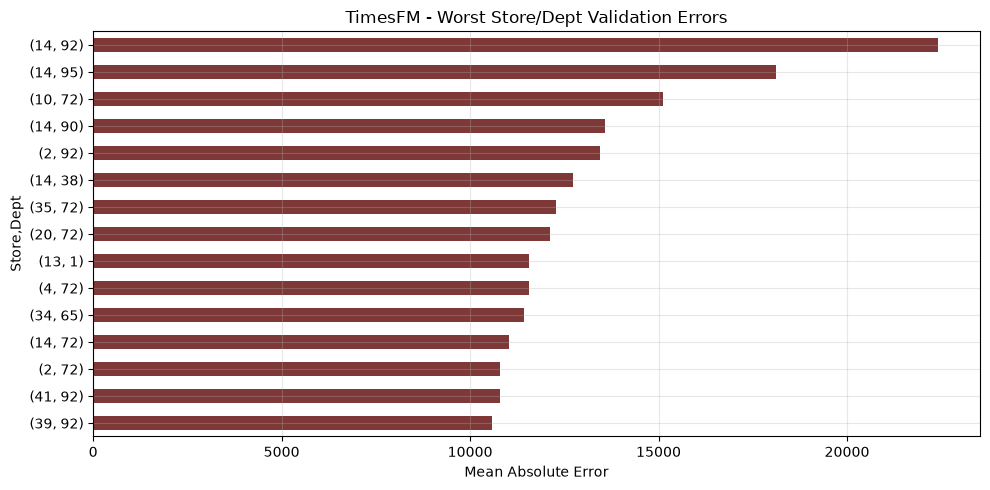

🏃 View run TimesFM_zero_shot_5 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/6/runs/aa247403c670487ea7cc4b5945c039e1
🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/6


holiday_week_mae,▁
nonholiday_week_mae,▁
holiday_week_mae,2155.75339
nonholiday_week_mae,1723.31689


In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
worst_store_dept.sort_values().plot(kind="barh", ax=ax, color=RED)
ax.set_xlabel("Mean Absolute Error")
ax.set_title("TimesFM - Worst Store/Dept Validation Errors")
ax.grid(True, alpha=0.3)
plt.tight_layout()
error_plot_path = "Plots/timesfm_worst_store_dept.png"
plt.savefig(error_plot_path, dpi=200)
plt.show()

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(error_plot_path)

wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    name="TimesFM_Error_Analysis",
    group="TimesFM",
    job_type="analysis",
    tags=["TimesFM", "error_analysis"],
    reinit=True,
)
wandb.log({
    "timesfm_worst_store_dept": wandb.Image(error_plot_path),
    "holiday_week_mae": float(holiday_error.get(True, np.nan)),
    "nonholiday_week_mae": float(holiday_error.get(False, np.nan)),
})
wandb.finish()

### 15. Best Model


In [18]:
print("Best label:", best_label)
print("Best run id:", best_run_id)
print("Best validation WMAE:", best_val_wmae)

best_row = results_df[results_df["label"] == best_label].iloc[0]
best_params = {
    "context_length": int(best_row["context_length"]),
    "use_covariates": bool(best_row["use_covariates"]),
    "xreg_mode": best_row["xreg_mode"] if best_row["use_covariates"] else None,
    "ridge": float(best_row["ridge"]) if best_row["use_covariates"] else None,
}
display(best_params)

fallback_by_id = long_df.sort_values("ds").groupby("unique_id")["y"].last().astype(float).to_dict()
global_fallback = float(long_df["y"].median())

print(f"Fallback values available for {len(fallback_by_id)} series")
print(f"Global fallback Weekly_Sales: {global_fallback:,.2f}")

# futr_cols (calendar/weather/economic/markdown/holiday) don't vary by Dept, but
# the real test set only has rows for weeks a department is active. Build a
# complete Store+Date reference table from features.csv so the pipeline can
# backfill exogenous values for dates a given store/dept series is missing.
store_date_features = build_store_date_features(load_features(), FUTR_COLS)

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_param("registered_model_name", "TimesFM_WalmartForecast")
    mlflow.log_metric("best_val_wmae", best_val_wmae)
    mlflow.log_param("repo_id", REPO_ID)
    # Keyed as "final_*" (not the bare sweep-loop names) because best_run_id is
    # the same nested run the sweep already logged params on, and MLflow
    # params are immutable per key - the sweep may have logged an empty string
    # here if the winning config didn't use covariates.
    mlflow.log_param(
        "final_future_exogenous_columns",
        ",".join(FUTR_COLS) if best_params["use_covariates"] else "",
    )
    mlflow.log_param("final_n_futr_cols", len(FUTR_COLS) if best_params["use_covariates"] else 0)
    mlflow.log_param("fallback_method", "last_observed_sales_by_store_dept")
    mlflow.log_metric("global_fallback_weekly_sales", global_fallback)
    mlflow.log_params({f"final_{k}": v for k, v in best_params.items()})
    # TimesFM's weights are frozen and pretrained by Google - we don't fine-tune
    # or save our own checkpoint, only the config used to call it, so there are
    # no gradients to log for the final model either.
    mlflow.log_param("final_gradient_logging", False)

pipeline_model = TimesFMForecastPipeline(
    repo_id=REPO_ID,
    history_long_df=timesfm_df,
    static_df=static_df,
    store_date_features=store_date_features,
    futr_cols=FUTR_COLS,
    static_num_cols=STATIC_NUM_COLS,
    static_cat_cols=STATIC_CAT_COLS,
    horizon=CONFIG["horizon"],
    context_length=best_params["context_length"],
    use_covariates=best_params["use_covariates"],
    xreg_mode=best_params["xreg_mode"] or "xreg + timesfm",
    ridge=best_params["ridge"] or 0.0,
    model_col=MODEL_COL,
    fallback_by_id=fallback_by_id,
    global_fallback=global_fallback,
)


class _SignatureContext:
    artifacts = {}


_temp = TimesFMForecastPipeline(
    repo_id=REPO_ID,
    history_long_df=timesfm_df,
    static_df=static_df,
    store_date_features=store_date_features,
    futr_cols=FUTR_COLS,
    static_num_cols=STATIC_NUM_COLS,
    static_cat_cols=STATIC_CAT_COLS,
    horizon=CONFIG["horizon"],
    context_length=best_params["context_length"],
    use_covariates=best_params["use_covariates"],
    xreg_mode=best_params["xreg_mode"] or "xreg + timesfm",
    ridge=best_params["ridge"] or 0.0,
    model_col=MODEL_COL,
    fallback_by_id=fallback_by_id,
    global_fallback=global_fallback,
)
_temp.load_context(_SignatureContext())
sample_output = _temp.predict(_SignatureContext(), test_df)
signature = infer_signature(test_df, sample_output)
display(sample_output.head())

with mlflow.start_run(run_id=best_run_id):
    logged_model_info = mlflow.pyfunc.log_model(
        artifact_path="pipeline",
        python_model=pipeline_model,
        code_paths=[str(repo_root / "src")],
        signature=signature,
        input_example=test_df.head(20),
        registered_model_name="TimesFM_WalmartForecast",
    )

model_uri = logged_model_info.model_uri
print("Logged model URI:", model_uri)

Best label: zero_shot_5
Best run id: aa247403c670487ea7cc4b5945c039e1
Best validation WMAE: 1815.324658335486


{'context_length': 104,
 'use_covariates': False,
 'xreg_mode': None,
 'ridge': None}

Fallback values available for 3331 series
Global fallback Weekly_Sales: 7,612.03
🏃 View run TimesFM_zero_shot_5 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/6/runs/aa247403c670487ea7cc4b5945c039e1
🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/6


c:\Users\l.chitishvili\Desktop\ml\ml-final-project-store-sales-forecasting\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


,Id,Weekly_Sales
0,1_1_2012-11-02,29104.417969
1,1_1_2012-11-09,23276.683594
2,1_1_2012-11-16,18747.955078
3,1_1_2012-11-23,19555.343750
4,1_1_2012-11-30,25276.042969


2026/07/12 22:21:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/12 22:21:53 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/07/12 22:21:53 INFO mlflow.pyfunc: Validating input example against model signature
2026/07/12 22:23:54 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\LFBD9~1.CHI\AppData\Local\Temp\tmpsi862xl9\model, flavor: python_function). Fall back to return ['cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 


Successfully registered model 'TimesFM_WalmartForecast'.
2026/07/12 22:28:04 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: TimesFM_WalmartForecast, version 1
Created version '1' of model 'TimesFM_WalmartForecast'.


🏃 View run TimesFM_zero_shot_5 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/6/runs/aa247403c670487ea7cc4b5945c039e1
🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/6
Logged model URI: models:/m-d28c7f9d70b84aeb9698d61f66c963b8


### 16. Test Loading


In [19]:
loaded_model = mlflow.pyfunc.load_model(model_uri)
loaded_preds = loaded_model.predict(test_df)
display(loaded_preds.head())
print("Loaded prediction shape:", loaded_preds.shape)
assert set(loaded_preds.columns) == {"Id", "Weekly_Sales"}
assert loaded_preds["Weekly_Sales"].notna().all()

,Id,Weekly_Sales
0,1_1_2012-11-02,29104.417969
1,1_1_2012-11-09,23276.683594
2,1_1_2012-11-16,18747.955078
3,1_1_2012-11-23,19555.343750
4,1_1_2012-11-30,25276.042969


Loaded prediction shape: (115064, 2)
